In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

In [2]:
## Dataset
from contra_seq_dataset import * 
import random

anc_path = 'data/model_ready/00/anchor_smiles.csv'
aug_path = 'data/model_ready/00/augmented_smiles_balanced.csv'
ds = ContraSeqDataset(anc_path, aug_path)
ds_arr = get_dataset_array(anc_path, aug_path)
anc_map = get_anc_map(ds_arr)

## Loader
from contra_seq_dataset import AnchoredSampler
from torch.utils.data import DataLoader, RandomSampler

BATCH_SIZE = 16 # this is the number of ANCHORS
randy = random.sample(range(10000), 512)
sampler = AnchoredSampler(sampler = randy, #RandomSampler(list(anc_map.keys())), 
                          anc_map = anc_map, batch_size = BATCH_SIZE, drop_last = True)
loader = DataLoader(ds, batch_sampler=sampler, num_workers=0, pin_memory=True)

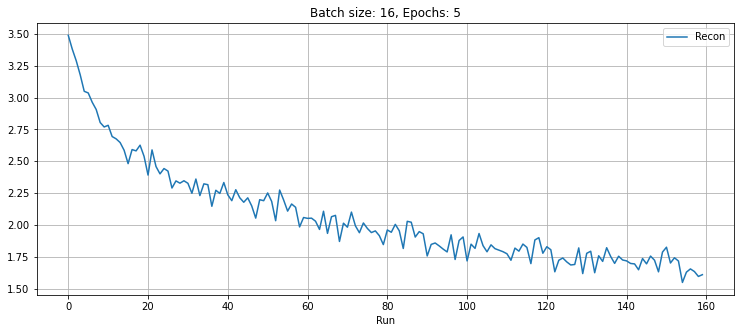

Epoch done. Runtime: 0 mins 15 secs.
All done. Total runtime: 0 hr 1  min 18 sec.


In [3]:
import torch
import torch.nn as nn
import pandas as pd

from seqAE_model import SeqAutoencoder
from training_functions import *

# ds, loader = get_ds_and_loader('00',32)

model = SeqAutoencoder(n_tokens = ds.n_tokens, max_len = 122,
                       dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

torch.cuda.empty_cache()
use_cuda = True
device =  torch.device("cuda" if use_cuda else "cpu")

if use_cuda and torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count()-1, "GPUs!")
    model = nn.DataParallel(model, device_ids = [0, 1, 2])
    model.to(device)
else:
    model = model.to(device)
    
optimizer = torch.optim.Adam(model.parameters(), lr = 0.00001) 

model.train()
torch.set_grad_enabled(True)

from training_functions import *

use_losses = ['Recon']
v = 'testa00'

today = datetime.today().strftime('%Y%m%d%H')
tag = f'{today}_{v}'

run_data = fit(model, device, optimizer, loader, use_losses, v, bs=16, n_epochs=5, 
               normed_latent=True, do_plot=True, save_fifths=True)

df_run = pd.DataFrame.from_dict(run_data)
df_run.to_csv(f'results/training_logs/losses_{tag}.csv')